<a href="https://colab.research.google.com/github/rudalshan0412-code/attention-is-all-you-need-pytorch/blob/main/14)_%ED%86%A0%EC%9D%B4%EB%8D%B0%EC%9D%B4%ED%84%B0_%ED%99%9C%EC%9A%A9_%EA%B2%80%EC%A6%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Google Drive 연결

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 프로젝트 경로 설정

from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/attention_is_all_you_need"
)

SRC_DIR = PROJECT_ROOT / "src"

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SRC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)

PROJECT_ROOT: /content/drive/MyDrive/attention_is_all_you_need
SRC_DIR: /content/drive/MyDrive/attention_is_all_you_need/src


In [ ]:
# 현재 src 파일 목록 확인

for file_path in sorted(SRC_DIR.glob("*.py")):
    print(file_path.name)

attention.py
dataset.py
decoder.py
decoder_layer.py
encoder.py
encoder_layer.py
feed_forward.py
mask.py
multi_head_attention.py
positional_encoding.py
tokenizer.py
transformer.py
vocabulary.py


In [ ]:
# 필요한 모듈 import

import math

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from src.transformer import Transformer

from src.tokenizer import tokenize

from src.vocabulary import (
    Vocabulary,
    PAD_IDX,
    UNK_IDX,
    BOS_IDX,
    EOS_IDX,
)

from src.dataset import (
    TranslationDataset,
    collate_fn,
)

from src.mask import (
    create_padding_mask,
    create_causal_mask,
)

In [ ]:
# 고정 인덱스 확인

print("PAD_IDX:", PAD_IDX)
print("UNK_IDX:", UNK_IDX)
print("BOS_IDX:", BOS_IDX)
print("EOS_IDX:", EOS_IDX)

assert PAD_IDX == 0
assert UNK_IDX == 1
assert BOS_IDX == 2
assert EOS_IDX == 3

print("Special token indices are correct.")

PAD_IDX: 0
UNK_IDX: 1
BOS_IDX: 2
EOS_IDX: 3
Special token indices are correct.


In [ ]:
# ENG -> KOR 병렬 데이터 준비

sentence_pairs = [
    ("I am happy.", "나는 행복하다."),
    ("I am tired.", "나는 피곤하다."),
    ("I am ready.", "나는 준비됐다."),
    ("You are happy.", "너는 행복하다."),
    ("You are tired.", "너는 피곤하다."),
    ("You are my friend.", "너는 나의 친구다."),
    ("He is my friend.", "그는 나의 친구다."),
    ("She is my friend.", "그녀는 나의 친구다."),
    ("He is happy.", "그는 행복하다."),
    ("She is happy.", "그녀는 행복하다."),

    ("I like apples.", "나는 사과를 좋아한다."),
    ("I like bread.", "나는 빵을 좋아한다."),
    ("I like music.", "나는 음악을 좋아한다."),
    ("You like apples.", "너는 사과를 좋아한다."),
    ("You like music.", "너는 음악을 좋아한다."),
    ("He likes apples.", "그는 사과를 좋아한다."),
    ("She likes apples.", "그녀는 사과를 좋아한다."),
    ("He likes music.", "그는 음악을 좋아한다."),
    ("She likes music.", "그녀는 음악을 좋아한다."),
    ("We like music.", "우리는 음악을 좋아한다."),

    ("I eat an apple.", "나는 사과를 먹는다."),
    ("I eat bread.", "나는 빵을 먹는다."),
    ("You eat an apple.", "너는 사과를 먹는다."),
    ("You eat bread.", "너는 빵을 먹는다."),
    ("He eats an apple.", "그는 사과를 먹는다."),
    ("She eats an apple.", "그녀는 사과를 먹는다."),
    ("We eat bread.", "우리는 빵을 먹는다."),
    ("They eat bread.", "그들은 빵을 먹는다."),

    ("I read a book.", "나는 책을 읽는다."),
    ("You read a book.", "너는 책을 읽는다."),
    ("He reads a book.", "그는 책을 읽는다."),
    ("She reads a book.", "그녀는 책을 읽는다."),
    ("We read a book.", "우리는 책을 읽는다."),
    ("They read a book.", "그들은 책을 읽는다."),

    ("I see a cat.", "나는 고양이를 본다."),
    ("I see a dog.", "나는 강아지를 본다."),
    ("You see a cat.", "너는 고양이를 본다."),
    ("You see a dog.", "너는 강아지를 본다."),
    ("He sees a cat.", "그는 고양이를 본다."),
    ("She sees a dog.", "그녀는 강아지를 본다."),

    ("The cat is small.", "고양이는 작다."),
    ("The dog is big.", "강아지는 크다."),
    ("The book is small.", "책은 작다."),
    ("The apple is red.", "사과는 빨갛다."),
    ("The house is big.", "집은 크다."),

    ("I have a book.", "나는 책을 가지고 있다."),
    ("I have a dog.", "나는 강아지를 가지고 있다."),
    ("You have a book.", "너는 책을 가지고 있다."),
    ("He has a dog.", "그는 강아지를 가지고 있다."),
    ("She has a cat.", "그녀는 고양이를 가지고 있다."),
]

In [ ]:
# 전체 데이터 개수 확인

print("전체 sentence pair 수:", len(sentence_pairs))

# 일부 확인

for i in range(5):
    source_sentence, target_sentence = sentence_pairs[i]

    print(f"[{i}]")
    print("Source:", source_sentence)
    print("Target:", target_sentence)
    print()

전체 sentence pair 수: 50
[0]
Source: I am happy.
Target: 나는 행복하다.

[1]
Source: I am tired.
Target: 나는 피곤하다.

[2]
Source: I am ready.
Target: 나는 준비됐다.

[3]
Source: You are happy.
Target: 너는 행복하다.

[4]
Source: You are tired.
Target: 너는 피곤하다.



In [ ]:
# Train / Validation 분리

# 이때, train에서 어느정도 사용한 단어 조합을 가진 문장으로 Validaion을 준비한다

validation_indices = [
    4,
    9,
    14,
    18,
    23,
    31,
    36,
    39,
    42,
    47,
]

train_pairs = [
    pair
    for i, pair in enumerate(sentence_pairs)
    if i not in validation_indices
]

val_pairs = [
    pair
    for i, pair in enumerate(sentence_pairs)
    if i in validation_indices
]

In [ ]:
# Train / Validation 개수 확인

print("Train pair 수:", len(train_pairs))
print("Validation pair 수:", len(val_pairs))

Train pair 수: 40
Validation pair 수: 10


In [ ]:
# Train Source / Target 예시 확인

print("Train 예시")

for i in range(3):
    print("Source:", train_pairs[i][0])
    print("Target:", train_pairs[i][1])
    print()

Train 예시
Source: I am happy.
Target: 나는 행복하다.

Source: I am tired.
Target: 나는 피곤하다.

Source: I am ready.
Target: 나는 준비됐다.



In [ ]:
# Validation Source / Target 예시 확인

print("Validation 예시")

for i in range(3):
    print("Source:", val_pairs[i][0])
    print("Target:", val_pairs[i][1])
    print()

Validation 예시
Source: You are tired.
Target: 너는 피곤하다.

Source: She is happy.
Target: 그녀는 행복하다.

Source: You like music.
Target: 너는 음악을 좋아한다.



In [ ]:
# Train Source / Target 분리

train_source_sentences = [
    source
    for source, target in train_pairs
]

train_target_sentences = [
    target
    for source, target in train_pairs
]

val_source_sentences = [
    source
    for source, target in val_pairs
]

val_target_sentences = [
    target
    for source, target in val_pairs
]

# 간단히 확인

print(train_source_sentences[:3])
print(train_target_sentences[:3])

print()

print(val_source_sentences[:3])
print(val_target_sentences[:3])

['I am happy.', 'I am tired.', 'I am ready.']
['나는 행복하다.', '나는 피곤하다.', '나는 준비됐다.']

['You are tired.', 'She is happy.', 'You like music.']
['너는 피곤하다.', '그녀는 행복하다.', '너는 음악을 좋아한다.']


In [ ]:
# Train Source Tokenization

source_example = train_source_sentences[0]

source_tokens = tokenize(
    source_example
)

print("Original:")
print(source_example)

print()

print("Tokens:")
print(source_tokens)

Original:
I am happy.

Tokens:
['i', 'am', 'happy', '.']


In [ ]:
# Train Target Tokenization

target_example = train_target_sentences[0]

target_tokens = tokenize(
    target_example
)

print("Original:")
print(target_example)

print()

print("Tokens:")
print(target_tokens)

Original:
나는 행복하다.

Tokens:
['나는', '행복하다', '.']


In [ ]:
# 복잡한 한국어 Tokenization 확인

test_source = "I like apples."
test_target = "나는 사과를 좋아한다."

print("Source Tokens:")
print(tokenize(test_source))

print()

print("Target Tokens:")
print(tokenize(test_target))

Source Tokens:
['i', 'like', 'apples', '.']

Target Tokens:
['나는', '사과를', '좋아한다', '.']


In [ ]:
# Train 전체 Tokenization 준비

tokenized_train_source = [
    tokenize(sentence)
    for sentence in train_source_sentences
]

tokenized_train_target = [
    tokenize(sentence)
    for sentence in train_target_sentences
]

# 몇개 확인

for i in range(3):
    print("Source:", train_source_sentences[i])
    print("Source Tokens:", tokenized_train_source[i])

    print("Target:", train_target_sentences[i])
    print("Target Tokens:", tokenized_train_target[i])

    print()

Source: I am happy.
Source Tokens: ['i', 'am', 'happy', '.']
Target: 나는 행복하다.
Target Tokens: ['나는', '행복하다', '.']

Source: I am tired.
Source Tokens: ['i', 'am', 'tired', '.']
Target: 나는 피곤하다.
Target Tokens: ['나는', '피곤하다', '.']

Source: I am ready.
Source Tokens: ['i', 'am', 'ready', '.']
Target: 나는 준비됐다.
Target Tokens: ['나는', '준비됐다', '.']



In [ ]:
# source vocabulary 생성

source_vocab = Vocabulary(
    tokenized_train_source
 )

In [ ]:
# Target Vocabulary 생성

target_vocab = Vocabulary(
    tokenized_train_target
)

In [ ]:
# Vocabulary 크기 확인

print("Source Vocabulary Size:", len(source_vocab))
print("Target Vocabulary Size:", len(target_vocab))

Source Vocabulary Size: 43
Target Vocabulary Size: 35


In [ ]:
# Sourc / Target Vocbulary가 독립인지 확인

print(
    "source_vocabulary == target_vocabulary:",
    source_vocab == target_vocab,
)

assert source_vocab != target_vocab

source_vocabulary == target_vocabulary: False


In [ ]:
# Special Token 확인

print("Source Vocabulary")

for i in range(4):
    print(
        i,
        source_vocab.id_to_token(i),
    )

print()

print("Target Vocabulary")

for i in range(4):
    print(
        i,
        target_vocab.id_to_token(i),
    )

Source Vocabulary
0 <PAD>
1 <UNK>
2 <BOS>
3 <EOS>

Target Vocabulary
0 <PAD>
1 <UNK>
2 <BOS>
3 <EOS>


In [ ]:
# Validation에서 UNK가 나타나는 경우


# vocabulary를 생성할 때 Validation을 사용하지 않았기에 Validation에만 존재하는 단어가 있다면 UNK(=1)로 나타낸다

for source_sentence, target_sentence in val_pairs:
    source_tokens = tokenize(source_sentence)
    target_tokens = tokenize(target_sentence)

    unknown_source = [
        token
        for token in source_tokens
        if token not in source_vocab.stoi
    ]

    unknown_target = [
        token
        for token in target_tokens
        if token not in target_vocab.stoi
    ]

    print("Source:", source_sentence)
    print("Source UNK:", unknown_source)

    print("Target:", target_sentence)
    print("Target UNK:", unknown_target)

    print()

Source: You are tired.
Source UNK: []
Target: 너는 피곤하다.
Target UNK: []

Source: She is happy.
Source UNK: []
Target: 그녀는 행복하다.
Target UNK: []

Source: You like music.
Source UNK: []
Target: 너는 음악을 좋아한다.
Target UNK: []

Source: She likes music.
Source UNK: []
Target: 그녀는 음악을 좋아한다.
Target UNK: []

Source: You eat bread.
Source UNK: []
Target: 너는 빵을 먹는다.
Target UNK: []

Source: She reads a book.
Source UNK: []
Target: 그녀는 책을 읽는다.
Target UNK: []

Source: You see a cat.
Source UNK: []
Target: 너는 고양이를 본다.
Target UNK: []

Source: She sees a dog.
Source UNK: []
Target: 그녀는 강아지를 본다.
Target UNK: []

Source: The book is small.
Source UNK: []
Target: 책은 작다.
Target UNK: ['책은']

Source: You have a book.
Source UNK: []
Target: 너는 책을 가지고 있다.
Target UNK: []



In [ ]:
# train Dataset

train_dataset = TranslationDataset(
    train_source_sentences,
    train_target_sentences,
    tokenize,
    tokenize,
    source_vocab,
    target_vocab,
)

In [ ]:
# Validation Dataset

val_dataset = TranslationDataset(
    val_source_sentences,
    val_target_sentences,
    tokenize,
    tokenize,
    source_vocab,
    target_vocab,
)

In [ ]:
# Dataset 길이 확인

print(
    "Train Dataset:",
    len(train_dataset),
)

print(
    "Validation Dataset:",
    len(val_dataset),
)

Train Dataset: 40
Validation Dataset: 10


In [ ]:
# Dataset Sample 확인

sample_source_ids, sample_target_ids = train_dataset[0]

print("Source IDs:")
print(sample_source_ids)

print()

print("Target IDs:")
print(sample_target_ids)

print()

print("Source dtype:")
print(sample_source_ids.dtype)

print()

print("Target dtype:")
print(sample_target_ids.dtype)

Source IDs:
tensor([2, 4, 5, 6, 7, 3])

Target IDs:
tensor([2, 4, 5, 6, 3])

Source dtype:
torch.int64

Target dtype:
torch.int64


In [ ]:
# BOS / EOS 확인

print(
    "Source first:",
    sample_source_ids[0].item(),
)

print(
    "Source last:",
    sample_source_ids[-1].item(),
)

print(
    "Target first:",
    sample_target_ids[0].item(),
)

print(
    "Target last:",
    sample_target_ids[-1].item(),
)

Source first: 2
Source last: 3
Target first: 2
Target last: 3


In [ ]:
# Train DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
)

In [ ]:
# Validation DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
)

In [ ]:
# Batch 하나 꺼내기

source_batch, target_batch = next(
    iter(train_loader)
)

In [ ]:
# Shape / dtype 확인

print(
    "source_batch shape:",
    source_batch.shape,
)

print(
    "target_batch shape:",
    target_batch.shape,
)

print()

print(
    "source_batch dtype:",
    source_batch.dtype,
)

print(
    "target_batch dtype:",
    target_batch.dtype,
)

source_batch shape: torch.Size([8, 7])
target_batch shape: torch.Size([8, 6])

source_batch dtype: torch.int64
target_batch dtype: torch.int64


In [ ]:
# Device 설정

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
# transformer 생성

transformer = Transformer(
    source_vocab_size=len(source_vocab),
    target_vocab_size=len(target_vocab),
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=50,
    dropout=0.1,
)

In [ ]:
# Device로 이동

transformer = transformer.to(
    device
)

In [ ]:
# Criterion

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

In [ ]:
# Optimizer

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-3,
)

In [ ]:
# training 전 한 Batch 흐름 검증

source_batch, target_batch = next(
    iter(train_loader)
)

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

In [ ]:
# Target shift

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

# shape

print(
    "target_batch:",
    target_batch.shape,
)

print(
    "decoder_input:",
    decoder_input.shape,
)

print(
    "labels:",
    labels.shape,
)

target_batch: torch.Size([8, 7])
decoder_input: torch.Size([8, 6])
labels: torch.Size([8, 6])


In [ ]:
# source mask

source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

print(
    "source_mask:",
    source_mask.shape,
)

source_mask: torch.Size([8, 1, 1, 7])


In [ ]:
# Target Padding Mask

target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

print(
    "target_padding_mask:",
    target_padding_mask.shape,
)

target_padding_mask: torch.Size([8, 1, 1, 6])


In [ ]:
# Casual Mask


causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=decoder_input.device,
)

print(
    "causal_mask:",
    causal_mask.shape,
)

causal_mask: torch.Size([1, 1, 6, 6])


In [ ]:
# Target Mask

target_mask = (
    target_padding_mask
    & causal_mask
)

print(
    "target_mask:",
    target_mask.shape,
)

target_mask: torch.Size([8, 1, 6, 6])


In [ ]:
# Transformer Forward

logits, _, _, _ = transformer(
    source_batch,
    decoder_input,
    source_mask,
    target_mask,
)

print(
    "logits:",
    logits.shape, # (B, T-1, tgt_vocab_size)
)

assert logits.size(-1) == len(target_vocab)

logits: torch.Size([8, 6, 35])


In [ ]:
# Loss 전 shape 확인

flattened_logits = logits.reshape(
    -1,
    logits.size(-1),
)

flattened_labels = labels.reshape(-1)

print(
    "flattened_logits:",
    flattened_logits.shape,
)

print(
    "flattened_labels:",
    flattened_labels.shape,
)

flattened_logits: torch.Size([48, 35])
flattened_labels: torch.Size([48])


In [ ]:
# Loss 계산

test_loss = criterion(
    flattened_logits,
    flattened_labels,
)

print(
    "Initial batch loss:",
    test_loss.item(),
)

Initial batch loss: 3.610466718673706


In [ ]:
# 전체 Training Loop

num_epochs = 200

train_loss_history = []
val_loss_history = []

for epoch in range(1, num_epochs + 1):

    transformer.train()

    train_loss_sum = 0.0

    for source_batch, target_batch in train_loader:

        source_batch = source_batch.to(device)
        target_batch = target_batch.to(device)

        decoder_input = target_batch[:, :-1]
        labels = target_batch[:, 1:]

        source_mask = create_padding_mask(
            source_batch,
            PAD_IDX,
        )

        target_padding_mask = create_padding_mask(
            decoder_input,
            PAD_IDX,
        )

        causal_mask = create_causal_mask(
            decoder_input.size(1),
            device=decoder_input.device,
        )

        target_mask = (
            target_padding_mask
            & causal_mask
        )

        optimizer.zero_grad()

        logits, _, _, _ = transformer(
            source_batch,
            decoder_input,
            source_mask,
            target_mask,
        )

        loss = criterion(
            logits.reshape(
                -1,
                logits.size(-1),
            ),
            labels.reshape(-1),
        )

        loss.backward()

        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum
        / len(train_loader)
    )

    transformer.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for source_batch, target_batch in val_loader:

            source_batch = source_batch.to(device)
            target_batch = target_batch.to(device)

            decoder_input = target_batch[:, :-1]
            labels = target_batch[:, 1:]

            source_mask = create_padding_mask(
                source_batch,
                PAD_IDX,
            )

            target_padding_mask = create_padding_mask(
                decoder_input,
                PAD_IDX,
            )

            causal_mask = create_causal_mask(
                decoder_input.size(1),
                device=decoder_input.device,
            )

            target_mask = (
                target_padding_mask
                & causal_mask
            )

            logits, _, _, _ = transformer(
                source_batch,
                decoder_input,
                source_mask,
                target_mask,
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                labels.reshape(-1),
            )

            val_loss_sum += loss.item()

    val_loss = (
        val_loss_sum
        / len(val_loader)
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    if epoch == 1 or epoch % 20 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch   1 | Train Loss: 3.1092 | Val Loss: 2.7042
Epoch  20 | Train Loss: 0.2310 | Val Loss: 0.7572
Epoch  40 | Train Loss: 0.0448 | Val Loss: 0.6372
Epoch  60 | Train Loss: 0.0197 | Val Loss: 0.6145
Epoch  80 | Train Loss: 0.0104 | Val Loss: 0.6504
Epoch 100 | Train Loss: 0.0074 | Val Loss: 0.6674
Epoch 120 | Train Loss: 0.0054 | Val Loss: 0.6788
Epoch 140 | Train Loss: 0.0040 | Val Loss: 0.7037
Epoch 160 | Train Loss: 0.0037 | Val Loss: 0.7044
Epoch 180 | Train Loss: 0.0030 | Val Loss: 0.7241
Epoch 200 | Train Loss: 0.0021 | Val Loss: 0.7412


In [ ]:
# 시작/마지막 loss 확인

print(
    "First Train Loss:",
    train_loss_history[0],
)

print(
    "Last Train Loss:",
    train_loss_history[-1],
)

print()

print(
    "First Validation Loss:",
    val_loss_history[0],
)

print(
    "Last Validation Loss:",
    val_loss_history[-1],
)

First Train Loss: 3.1092111587524416
Last Train Loss: 0.0020522664999589324

First Validation Loss: 2.704150438308716
Last Validation Loss: 0.7412260556593537


In [ ]:
# Validation Loss 최저점 확인

best_val_loss = min(
    val_loss_history
)

best_val_epoch = (
    val_loss_history.index(
        best_val_loss
    )
    + 1
)

print(
    "Best Validation Loss:",
    best_val_loss,
)

print(
    "Best Validation Epoch:",
    best_val_epoch,
)

Best Validation Loss: 0.6108440794050694
Best Validation Epoch: 58


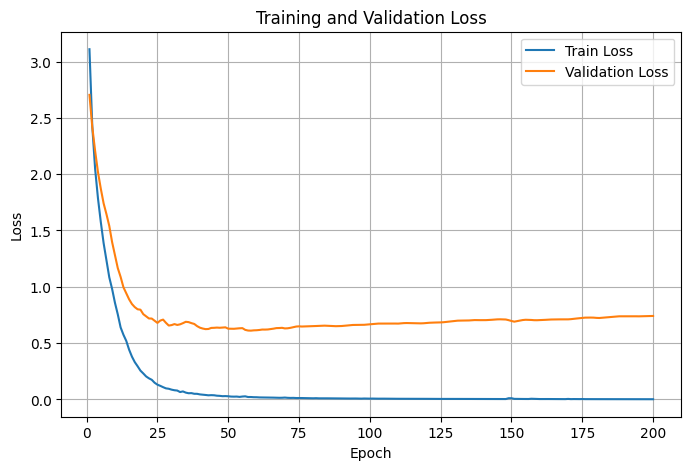

In [ ]:
# Train / Validation Loss Graph

epochs = range(
    1,
    num_epochs + 1,
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    train_loss_history,
    label="Train Loss",
)

plt.plot(
    epochs,
    val_loss_history,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Greedy Decoding 함수

def greedy_decode(
    source_sentence,
    transformer,
    source_vocab,
    target_vocab,
    max_generation_length=20,
):

    transformer.eval()

    source_tokens = tokenize(
        source_sentence
    )

    source_ids = [
        BOS_IDX
    ] + source_vocab.encode(
        source_tokens
    ) + [
        EOS_IDX
    ]

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    source_mask = create_padding_mask(
        source_tensor,
        PAD_IDX,
    )

    generated_ids = torch.tensor(
        [[BOS_IDX]],
        dtype=torch.long,
        device=device,
    )

    with torch.no_grad():

        for _ in range(
            max_generation_length - 1
        ):

            target_padding_mask = (
                create_padding_mask(
                    generated_ids,
                    PAD_IDX,
                )
            )

            causal_mask = (
                create_causal_mask(
                    generated_ids.size(1),
                    device=generated_ids.device,
                )
            )

            target_mask = (
                target_padding_mask
                & causal_mask
            )

            logits, _, _, _ = transformer(
                source_tensor,
                generated_ids,
                source_mask,
                target_mask,
            )

            next_token_logits = (
                logits[:, -1, :]
            )

            next_token_id = torch.argmax(
                next_token_logits,
                dim=-1,
            )

            generated_ids = torch.cat(
                [
                    generated_ids,
                    next_token_id.unsqueeze(1),
                ],
                dim=1,
            )

            if (
                next_token_id.item()
                == EOS_IDX
            ):
                break

    generated_ids_list = (
        generated_ids
        .squeeze(0)
        .tolist()
    )

    decoded_tokens = target_vocab.decode(
        generated_ids_list
    )

    clean_tokens = [
        token
        for token in decoded_tokens
        if token not in [
            "<PAD>",
            "<BOS>",
            "<EOS>",
        ]
    ]

    prediction = " ".join(
        clean_tokens
    )

    prediction = (
        prediction
        .replace(" .", ".")
        .replace(" ,", ",")
        .replace(" !", "!")
        .replace(" ?", "?")
    )

    return (
        prediction,
        clean_tokens,
        generated_ids_list,
    )

In [ ]:
# Training Source Inference

# train 문장 하나 선택

train_source = train_pairs[0][0]
train_reference = train_pairs[0][1]

# 번역

train_prediction, train_tokens, train_ids = (
    greedy_decode(
        train_source,
        transformer,
        source_vocab,
        target_vocab,
    )
)

# 출력

print("Source:")
print(train_source)

print()

print("Reference:")
print(train_reference)

print()

print("Prediction:")
print(train_prediction)

print()

print("Generated Token IDs:")
print(train_ids)

print()

print("Generated Tokens:")
print(train_tokens)

Source:
I am happy.

Reference:
나는 행복하다.

Prediction:
나는 행복하다.

Generated Token IDs:
[2, 4, 5, 6, 3]

Generated Tokens:
['나는', '행복하다', '.']


In [ ]:
# Validation Source Inference

# validation 문장 하나 선택

val_source = val_pairs[0][0]
val_reference = val_pairs[0][1]

# inference

val_prediction, val_tokens, val_ids = (
    greedy_decode(
        val_source,
        transformer,
        source_vocab,
        target_vocab,
    )
)

# 출력

print("Source:")
print(val_source)

print()

print("Reference:")
print(val_reference)

print()

print("Prediction:")
print(val_prediction)

print()

print("Generated Token IDs:")
print(val_ids)

print()

print("Generated Tokens:")
print(val_tokens)

Source:
You are tired.

Reference:
너는 피곤하다.

Prediction:
너는 피곤하다.

Generated Token IDs:
[2, 9, 7, 6, 3]

Generated Tokens:
['너는', '피곤하다', '.']


In [ ]:
# Training Sample 추가 확인

for i in range(5):

    source = train_pairs[i][0]
    reference = train_pairs[i][1]

    prediction, _, _ = greedy_decode(
        source,
        transformer,
        source_vocab,
        target_vocab,
    )

    print("Source:")
    print(source)

    print("Reference:")
    print(reference)

    print("Prediction:")
    print(prediction)

    print("-" * 40)

Source:
I am happy.
Reference:
나는 행복하다.
Prediction:
나는 행복하다.
----------------------------------------
Source:
I am tired.
Reference:
나는 피곤하다.
Prediction:
나는 피곤하다.
----------------------------------------
Source:
I am ready.
Reference:
나는 준비됐다.
Prediction:
나는 준비됐다.
----------------------------------------
Source:
You are happy.
Reference:
너는 행복하다.
Prediction:
너는 행복하다.
----------------------------------------
Source:
You are my friend.
Reference:
너는 나의 친구다.
Prediction:
너는 나의 친구다.
----------------------------------------


In [ ]:
# Validation Sample 추가 확인

for i in range(5):

    source = val_pairs[i][0]
    reference = val_pairs[i][1]

    prediction, _, _ = greedy_decode(
        source,
        transformer,
        source_vocab,
        target_vocab,
    )

    print("Source:")
    print(source)

    print("Reference:")
    print(reference)

    print("Prediction:")
    print(prediction)

    print("-" * 40)

Source:
You are tired.
Reference:
너는 피곤하다.
Prediction:
너는 피곤하다.
----------------------------------------
Source:
She is happy.
Reference:
그녀는 행복하다.
Prediction:
그녀는 행복하다.
----------------------------------------
Source:
You like music.
Reference:
너는 음악을 좋아한다.
Prediction:
너는 음악을 좋아한다.
----------------------------------------
Source:
She likes music.
Reference:
그녀는 음악을 좋아한다.
Prediction:
그녀는 음악을 좋아한다.
----------------------------------------
Source:
You eat bread.
Reference:
너는 빵을 먹는다.
Prediction:
너는 빵을 먹는다.
----------------------------------------


In [ ]:
# Overfitting 확인

print(
    "First Train Loss:",
    train_loss_history[0],
)

print(
    "Last Train Loss:",
    train_loss_history[-1],
)

print()

print(
    "Best Val Loss:",
    min(val_loss_history),
)

print(
    "Last Val Loss:",
    val_loss_history[-1],
)

First Train Loss: 3.1092111587524416
Last Train Loss: 0.0020522664999589324

Best Val Loss: 0.6108440794050694
Last Val Loss: 0.7412260556593537


In [ ]:
# 최종 통합 테스트

assert PAD_IDX == 0
assert UNK_IDX == 1
assert BOS_IDX == 2
assert EOS_IDX == 3

assert source_vocab is not target_vocab

assert len(train_dataset) == 40
assert len(val_dataset) == 10

sample_source, sample_target = (
    train_dataset[0]
)

assert sample_source.dtype == torch.long
assert sample_target.dtype == torch.long

assert sample_source[0].item() == BOS_IDX
assert sample_source[-1].item() == EOS_IDX

assert sample_target[0].item() == BOS_IDX
assert sample_target[-1].item() == EOS_IDX


source_batch, target_batch = next(
    iter(train_loader)
)

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

assert (
    decoder_input.size(1)
    == target_batch.size(1) - 1
)

assert (
    labels.size(1)
    == target_batch.size(1) - 1
)


source_batch = source_batch.to(device)
decoder_input = decoder_input.to(device)
labels = labels.to(device)


source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=device,
)

target_mask = (
    target_padding_mask
    & causal_mask
)


assert source_mask.shape == (
    source_batch.size(0),
    1,
    1,
    source_batch.size(1),
)

assert target_padding_mask.shape == (
    decoder_input.size(0),
    1,
    1,
    decoder_input.size(1),
)

assert causal_mask.shape == (
    1,
    1,
    decoder_input.size(1),
    decoder_input.size(1),
)

assert target_mask.shape == (
    decoder_input.size(0),
    1,
    decoder_input.size(1),
    decoder_input.size(1),
)


transformer.eval()

with torch.no_grad():

    logits, _, _, _ = transformer(
        source_batch,
        decoder_input,
        source_mask,
        target_mask,
    )


assert logits.size(-1) == len(
    target_vocab
)


test_loss = criterion(
    logits.reshape(
        -1,
        logits.size(-1),
    ),
    labels.reshape(-1),
)

assert torch.isfinite(
    test_loss
)


assert len(train_loss_history) == num_epochs
assert len(val_loss_history) == num_epochs

assert (
    train_loss_history[-1]
    < train_loss_history[0]
)


test_source = train_pairs[0][0]

prediction, generated_tokens, generated_ids = (
    greedy_decode(
        test_source,
        transformer,
        source_vocab,
        target_vocab,
    )
)


assert isinstance(
    generated_ids,
    list,
)

assert isinstance(
    generated_tokens,
    list,
)

assert "<PAD>" not in generated_tokens
assert "<BOS>" not in generated_tokens
assert "<EOS>" not in generated_tokens


print("Final Integration Test Passed ✅")

Final Integration Test Passed ✅
